In [7]:
import pandas as pd
import numpy as np

#1 читаем данные из файла Excel
# пропускаем шапку, которая занимает первые 4 строки
df_raw = pd.read_excel('sales_summer.xlsx', header=4)

#2 сначала отсекаем строки промежуточных итогов смены и чеков
#В реальной позиции чек никогда не содержит слово "всего", а поле "Блюдо" не пустое
mask_valid_rows = (
    df_raw['Блюдо'].notna() &
    ~df_raw['Номер чека'].astype(str).str.contains('всего', na=False) &
    ~df_raw['Номер смены'].astype(str).str.contains('всего', na=False)
)

# 3. Заполняем пропуски (протягиваем вниз) ТОЛЬКО до того, как удалим служебное
fill_cols = ['Торговое предприятие', 'Номер смены', 'Время открытия', 'Номер чека']

# Заменяем строки с "всего" на NaN перед протяжкой, чтобы они не копировались вниз
for col in ['Номер чека', 'Номер смены']:
    df_raw.loc[df_raw[col].astype(str).str.contains('всего', na=False), col] = np.nan

# Теперь безопасно протягиваем значения вниз
df_raw[fill_cols] = df_raw[fill_cols].ffill()


# 4. Оставляем только строки, где реально есть проданное блюдо
df = df_raw[df_raw['Блюдо'].notna()].copy() 

In [8]:
print(f"Всего чистых строк продаж: {len(df)}")
df.head(10)

Всего чистых строк продаж: 346228


,Торговое предприятие,Номер смены,Время открытия,Номер чека,Блюдо,Категория блюда,Количество блюд,"Сумма со скидкой, р.","Себестоимость, р."
0,Ж-А М1 Перв,133,2026-06-01 08:00:59,5,Чизкейк,Пироги,1.0,280.00,74.020000
1,Ж-А М1 Перв,133,2026-06-01 08:02:22,7,- Круассан шоколад,NaN,1.0,0.00,0.000000
2,Ж-А М1 Перв,133,2026-06-01 08:02:22,7,Круассан с начинкой,Выпечка,1.0,110.00,40.000000
3,Ж-А М1 Перв,133,2026-06-01 08:02:22,7,Пакет бумажный маленький,Сопутствующие товары,1.0,0.00,1.015333
5,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,- Круассан вишня,NaN,1.0,0.00,0.000000
6,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,- Симит кунжут,NaN,1.0,0.00,0.000000
7,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,- Сироп,NaN,1.0,40.00,14.794000
8,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,Круассан с начинкой,Выпечка,1.0,44.39,40.000000
9,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,Латте 350мл,Кофе,2.0,371.22,87.838462
10,Ж-А М1 Перв,133,2026-06-01 08:02:57,8,Пакет бумажный маленький,Сопутствующие товары,1.0,0.00,1.015333


In [12]:
# 1. Уникальный ID заказа (композитный ключ)
df['order_id'] = (
    df['Торговое предприятие'].astype(str) + '_' +
    df['Номер смены'].astype(str) + '_' +
    df['Время открытия'].astype(str).str.slice(0, 10) + '_' + 
    df['Номер чека'].astype(str)
)

# 2. Преобразуем время в datetime и вытягиваем признаки
df['datetime'] = pd.to_datetime(df['Время открытия'])
df['date'] = df['datetime'].dt.date
df['month'] = df['datetime'].dt.month_name()
df['day_of_week'] = df['datetime'].dt.day_name()
df['hour'] = df['datetime'].dt.hour
df['is_weekend'] = df['datetime'].dt.weekday.isin([5, 6])

# 3. Базовые финансовые метрики строки
df['margin'] = df['Сумма со скидкой, р.'] - df['Себестоимость, р.']

# 4. Проверяем сводку по датасету
print(f"Период данных: с {df['date'].min()} по {df['date'].max()}")
print(f"Всего уникальных чеков: {df['order_id'].nunique():,}")
print(f"Точки в датасете: {df['Торговое предприятие'].unique()}")

Период данных: с 2026-06-01 по 2026-08-31
Всего уникальных чеков: 82,314
Точки в датасете: <StringArray>
['Ж-А М1 Перв', 'Ж-А М2 Прол', 'Ж-А М3 Шосс']
Length: 3, dtype: str


In [16]:
# 1. Задаем правильный порядок месяцев лета
month_order = ['June', 'July', 'August']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# 2. Агрегация по точкам и месяцам
monthly_metrics = df.groupby(['Торговое предприятие', 'month']).agg(
    выручка=('Сумма со скидкой, р.', 'sum'),
    себестоимость=('Себестоимость, р.', 'sum'),
    маржа=('margin', 'sum'),
    чеков=('order_id', 'nunique'),
    кол_во_позиций=('Количество блюд', 'sum')
).reset_index()

# 3. Расчет удельных метрик
monthly_metrics['food_cost_%'] = (monthly_metrics['себестоимость'] / monthly_metrics['выручка'] * 100).round(2)
monthly_metrics['средний_чек'] = (monthly_metrics['выручка'] / monthly_metrics['чеков']).round(2)
monthly_metrics['глубина_чека'] = (monthly_metrics['кол_во_позиций'] / monthly_metrics['чеков']).round(2)

# 4. Форматирование для читаемости
monthly_metrics_styled = monthly_metrics.copy()
monthly_metrics_styled['выручка'] = monthly_metrics_styled['выручка'].map('{:,.0f} ₽'.format)
monthly_metrics_styled['маржа'] = monthly_metrics_styled['маржа'].map('{:,.0f} ₽'.format)
monthly_metrics_styled['себестоимость'] = monthly_metrics_styled['себестоимость'].map('{:,.0f} ₽'.format)

# Сортируем по точке и месяцу
monthly_metrics_styled.sort_values(['Торговое предприятие', 'month'])[
    ['Торговое предприятие', 'month', 'чеков', 'выручка', 'маржа', 
     'food_cost_%', 'средний_чек', 'глубина_чека']
]

,Торговое предприятие,month,чеков,выручка,маржа,food_cost_%,средний_чек,глубина_чека
0,Ж-А М1 Перв,June,9540,"4,556,842 ₽","2,732,764 ₽",40.03,477.66,5.30
1,Ж-А М1 Перв,July,9664,"4,875,998 ₽","3,020,844 ₽",38.05,504.55,5.24
2,Ж-А М1 Перв,August,8804,"4,714,972 ₽","2,952,357 ₽",37.38,535.55,5.68
3,Ж-А М2 Прол,June,7601,"5,018,331 ₽","3,277,355 ₽",34.69,660.22,8.45
4,Ж-А М2 Прол,July,9939,"5,109,365 ₽","3,342,360 ₽",34.58,514.07,6.32
5,Ж-А М2 Прол,August,12353,"5,717,433 ₽","3,731,632 ₽",34.73,462.84,5.67
6,Ж-А М3 Шосс,June,7645,"2,926,957 ₽","1,931,613 ₽",34.01,382.86,4.78
7,Ж-А М3 Шосс,July,8057,"3,173,496 ₽","2,095,992 ₽",33.95,393.88,4.64
8,Ж-А М3 Шосс,August,8711,"3,472,345 ₽","2,279,465 ₽",34.35,398.62,4.57


In [18]:
# 1. Смотрим топ модификаторов со знаком "-"
mod_mask = df['Блюдо'].astype(str).str.startswith('-')
print("--- ТОП МОДИФИКАТОРОВ (со знаком '-') ---")
print(df[mod_mask]['Блюдо'].value_counts().head(15))

# 2. Смотрим базовые позиции выпечки, куда эти вкусы могли относиться
print("\n--- БАЗОВЫЕ ПОЗИЦИИ ВЫПЕЧКИ ---")
base_mask = df['Блюдо'].astype(str).str.contains('Круассан|Симит|Эскарго|Рулет', case=False, na=False)
print(df[base_mask]['Блюдо'].value_counts().head(20))

--- ТОП МОДИФИКАТОРОВ (со знаком '-') ---
Блюдо
- Сахар кофе            3186
- Сироп                 2387
- Корица                1496
- Тёмная                1408
- Смородина             1238
- Кола 0.33             1030
- Малина                 962
- Клубника               899
- Круассан сыр           831
- Круассан вишня         764
- Пепси 0.33             722
- Лимон долька           690
- Круассан смородина     671
- Бамбл апельсин         632
- Кокос                  623
Name: count, dtype: int64

--- БАЗОВЫЕ ПОЗИЦИИ ВЫПЕЧКИ ---
Блюдо
Круассан сыр                5893
Круассан вишня              5210
Круассан смородина          4520
Рулет с маком               4406
Круассан шоколад            4223
Круассан сгущенка           3949
Эскарго яблоко              3391
Круассан шоколад-орех       3335
Рулет с орехом              3235
Круассан с начинкой         3013
Эскарго изюм                2478
Симит кунжут                1561
Симит мак                   1154
Рулет меренговый ягодны

In [19]:
check_croissant = df[df['Блюдо'].astype(str).str.contains('Круассан', case=False, na=False)]
check_croissant.groupby('Блюдо').agg(
    строк=('Блюдо', 'count'),
    кол_во=('Количество блюд', 'sum'),
    выручка=('Сумма со скидкой, р.', 'sum')
).sort_values('выручка', ascending=False).head(15)

,строк,кол_во,выручка
Блюдо,,,
Круассан сыр,5893,8861.0,746428.36
Круассан вишня,5210,7623.0,673344.12
Круассан смородина,4520,6580.0,575495.62
Круассан шоколад,4223,6162.0,528388.67
Круассан сгущенка,3949,5767.0,496847.94
Круассан с начинкой,3013,5444.0,448965.02
Круассан шоколад-орех,3335,4851.0,409002.23
Круассан натюр,649,1250.0,113245.04
Круассан с кремом заварным,149,204.0,36632.36


In [20]:
# 1. Задаем список целевых категорий с модификаторами
target_words = 'Круассан|Симит|Эскарго|Рулет'

# 2. Фильтруем строки модификаторов по этим группам
mod_rows = df[
    df['Блюдо'].astype(str).str.startswith('-') & 
    df['Блюдо'].astype(str).str.contains(target_words, case=False, na=False)
].copy()

# Очищаем название от дефиса в начале: "- Круассан вишня" -> "Круассан вишня"
mod_rows['clean_dish'] = mod_rows['Блюдо'].str.replace(r'^-\s*', '', regex=True).str.strip()

print(f"Всего строк модификаторов выпечки: {len(mod_rows)}")
print("\nРаспределение модификаторов вкусов:")
print(mod_rows['clean_dish'].value_counts())

Всего строк модификаторов выпечки: 5657

Распределение модификаторов вкусов:
clean_dish
Круассан сыр               831
Круассан вишня             764
Круассан смородина         671
Круассан шоколад           619
Круассан сгущёнка          536
Круассан шоколад - орех    489
Эскарго яблоко             488
Эскарго изюм               360
Рулет с орехом             303
Рулет с маком              244
Симит кунжут               210
Симит мак                  142
Name: count, dtype: int64


In [21]:
# Проверяем точные названия базовых строк для эскарго, симитов и рулетов
base_check = df[
    df['Блюдо'].astype(str).str.contains('Симит|Эскарго|Рулет', case=False, na=False) &
    ~df['Блюдо'].astype(str).str.startswith('-')
]

base_check.groupby('Блюдо').agg(
    строк=('Блюдо', 'count'),
    кол_во=('Количество блюд', 'sum'),
    выручка=('Сумма со скидкой, р.', 'sum')
).sort_values('выручка', ascending=False)

,строк,кол_во,выручка
Блюдо,,,
Рулет с маком,4406,10983.0,567473.25
Эскарго яблоко,3391,4635.0,391057.73
Рулет с орехом,3235,7573.0,388275.24
Рулет меренговый ягодный,1138,1519.0,378694.76
Эскарго изюм,2478,3358.0,288320.86
Симит кунжут,1561,2113.0,201717.22
Симит мак,1154,1494.0,147812.49
Эскарго,794,1151.0,97367.78
Рулет с начинкой,471,1376.0,72172.54


In [23]:
# 1. Приводим колонку "Блюдо" к типу object, чтобы исключить конфликт типов
df['Блюдо'] = df['Блюдо'].astype(object)

# 2. Словарь соответствия базовых строк ключевым словам вкусов
base_mapping = {
    'Круассан с начинкой': 'Круассан',
    'Эскарго': 'Эскарго',
    'Рулет с начинкой': 'Рулет',
    'Симит': 'Симит'
}

# 3. Находим строки модификаторов выпечки
target_mod_mask = (
    df['Блюдо'].astype(str).str.startswith('-') & 
    df['Блюдо'].astype(str).str.contains('Круассан|Симит|Эскарго|Рулет', case=False, na=False)
)

# 4. Собираем чистые вкусы
clean_names = df.loc[target_mod_mask, 'Блюдо'].astype(str).str.replace(r'^-\s*', '', regex=True).str.strip()

# 5. Для каждой категории передаем реальный вкус на базовую позицию внутри одного чека
for base_dish, keyword in base_mapping.items():
    # Фильтруем чеки с модификатором текущей группы
    subset_mask = target_mod_mask & df['Блюдо'].astype(str).str.contains(keyword, case=False, na=False)
    
    # Создаем словарь {order_id: правильный_вкус}
    mod_dict = dict(zip(df.loc[subset_mask, 'order_id'], clean_names[subset_mask]))
    
    # Находим базовые строки и подставляем вкус через векторный map
    target_rows = df['Блюдо'] == base_dish
    mapped_values = df.loc[target_rows, 'order_id'].map(mod_dict)
    
    # Заменяем только там, где нашлось соответствие вкуса
    df.loc[target_rows & mapped_values.notna(), 'Блюдо'] = mapped_values[mapped_values.notna()]

# 6. Удаляем строки модификаторов выпечки с суммой 0
df = df[~target_mod_mask].copy()

# 7. Проверяем остаток
check_remaining = df[df['Блюдо'].isin(base_mapping.keys())]['Блюдо'].value_counts()
print(f"Остаток базовых строк без модификатора: {check_remaining.to_dict()}")
print(f"Чистых строк после склейки: {len(df):,}")

Остаток базовых строк без модификатора: {}
Чистых строк после склейки: 340,571


In [24]:
# 1. Агрегируем продажи на уровне каждого блюда
menu_analysis = df.groupby('Блюдо').agg(
    выручка=('Сумма со скидкой, р.', 'sum'),
    себестоимость=('Себестоимость, р.', 'sum'),
    маржа=('margin', 'sum'),
    кол_во=('Количество блюд', 'sum'),
    чеков=('order_id', 'nunique')
).reset_index()

# 2. Функция расчета категорий ABC
def get_abc_category(df_in, target_col):
    df_sorted = df_in.sort_values(by=target_col, ascending=False).copy()
    total_val = df_sorted[target_col].sum()
    df_sorted['share'] = df_sorted[target_col] / total_val
    df_sorted['cum_share'] = df_sorted['share'].cumsum()
    
    # Границы: 80% для А, до 95% для B, остаток для C
    conditions = [
        df_sorted['cum_share'] <= 0.80,
        df_sorted['cum_share'] <= 0.95
    ]
    choices = ['A', 'B']
    df_sorted['abc_' + target_col] = np.select(conditions, choices, default='C')
    return df_sorted[['Блюдо', 'abc_' + target_col]]

# 3. Рассчитываем ABC по выручке и по марже
abc_rev = get_abc_category(menu_analysis, 'выручка')
abc_margin = get_abc_category(menu_analysis, 'маржа')

# 4. Объединяем в общую матрицу
menu_analysis = menu_analysis.merge(abc_rev, on='Блюдо').merge(abc_margin, on='Блюдо')
menu_analysis['abc_matrix'] = menu_analysis['abc_выручка'] + menu_analysis['abc_маржа']

# Расчет Food Cost %
menu_analysis['food_cost_%'] = (menu_analysis['себестоимость'] / menu_analysis['выручка'] * 100).round(2)

# 5. Сводка по матрице ABC
matrix_summary = menu_analysis.groupby('abc_matrix').agg(
    позиций=('Блюдо', 'count'),
    выручка=('выручка', 'sum'),
    маржа=('маржа', 'sum')
).reset_index()

matrix_summary['доля_выручки_%'] = (matrix_summary['выручка'] / menu_analysis['выручка'].sum() * 100).round(2)
matrix_summary['доля_маржи_%'] = (matrix_summary['маржа'] / menu_analysis['маржа'].sum() * 100).round(2)

print("--- СВОДКА ПО МАТРИЦЕ ABC/ABC ---")
print(matrix_summary.to_string(index=False))

--- СВОДКА ПО МАТРИЦЕ ABC/ABC ---
abc_matrix  позиций     выручка        маржа  доля_выручки_%  доля_маржи_%
        AA       64 30251699.42 1.963542e+07           76.46         77.41
        AB        5  1266556.65 4.365551e+05            3.20          1.72
        BA        5   821208.62 5.925062e+05            2.08          2.34
        BB       51  4822502.92 3.340785e+06           12.19         13.17
        BC        8   390706.28 1.966386e+05            0.99          0.78
        CB        2    82476.63 6.868549e+04            0.21          0.27
        CC      223  1930588.48 1.093790e+06            4.88          4.31


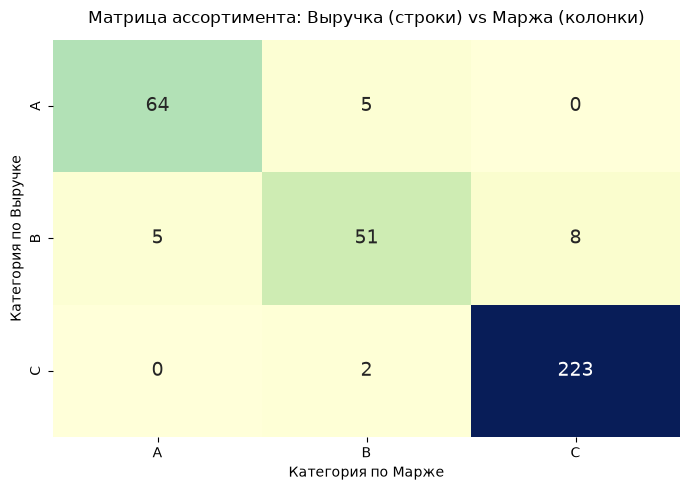

=== ТОП-10 ЗВЕЗД МЕНЮ (ГРУППА AA) ===
                   Блюдо    кол_во     выручка       маржа  food_cost_%
Клаб- сэндвич с индейкой  6761.000 1,411,829 ₽ 1,093,045 ₽        22.58
 Клаб- сэндвич с курицей  6647.000 1,387,141 ₽ 1,044,646 ₽        24.69
         Капучино 350 мл  5964.000 1,192,710 ₽   859,402 ₽        27.95
             Панини Пуле  6522.000 1,100,279 ₽   775,710 ₽        29.50
    Чиабатта на закваске 20442.000 1,016,597 ₽   687,514 ₽        32.37
           Торт Марадона   425.875   825,741 ₽   686,183 ₽        16.90
  Клаб - сэндвич с рыбой  2816.000 1,007,662 ₽   612,733 ₽        39.19
         Американо 250мл  4904.000   659,571 ₽   492,938 ₽        25.26
              Айс- латте  2765.000   613,804 ₽   453,016 ₽        26.20
         Ачма с индейкой  2682.000   638,661 ₽   441,357 ₽        30.89

=== ГРУППА РИСКА (AB и BC: высокая выручка при низкой марже) ===
                    Блюдо  кол_во   выручка     маржа  food_cost_%
             Салат цезарь  516.00 205

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Построение тепловой карты матрицы ABC/ABC
matrix_pivot = pd.crosstab(
    menu_analysis['abc_выручка'], 
    menu_analysis['abc_маржа'], 
    values=menu_analysis['Блюдо'], 
    aggfunc='count'
).reindex(index=['A', 'B', 'C'], columns=['A', 'B', 'C']).fillna(0)

plt.figure(figsize=(7, 5))
sns.heatmap(matrix_pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar=False, annot_kws={"size": 14})
plt.title('Матрица ассортимента: Выручка (строки) vs Маржа (колонки)', fontsize=12, pad=12)
plt.xlabel('Категория по Марже', fontsize=10)
plt.ylabel('Категория по Выручке', fontsize=10)
plt.tight_layout()
plt.show()

# 2. Топ-10 ключевых позиций группы AA (Флагманы)
print("=== ТОП-10 ЗВЕЗД МЕНЮ (ГРУППА AA) ===")
top_aa = menu_analysis[menu_analysis['abc_matrix'] == 'AA'].sort_values('маржа', ascending=False).head(10)
display_cols = ['Блюдо', 'кол_во', 'выручка', 'маржа', 'food_cost_%']

top_aa_styled = top_aa[display_cols].copy()
top_aa_styled['выручка'] = top_aa_styled['выручка'].map('{:,.0f} ₽'.format)
top_aa_styled['маржа'] = top_aa_styled['маржа'].map('{:,.0f} ₽'.format)
print(top_aa_styled.to_string(index=False))

# 3. Позиции группы риска (Выручка A/B, но маржа B/C)
print("\n=== ГРУППА РИСКА (AB и BC: высокая выручка при низкой марже) ===")
risk_group = menu_analysis[menu_analysis['abc_matrix'].isin(['AB', 'BC'])].sort_values('food_cost_%', ascending=False)
risk_styled = risk_group[display_cols].copy()
risk_styled['выручка'] = risk_styled['выручка'].map('{:,.0f} ₽'.format)
risk_styled['маржа'] = risk_styled['маржа'].map('{:,.0f} ₽'.format)
print(risk_styled.to_string(index=False))

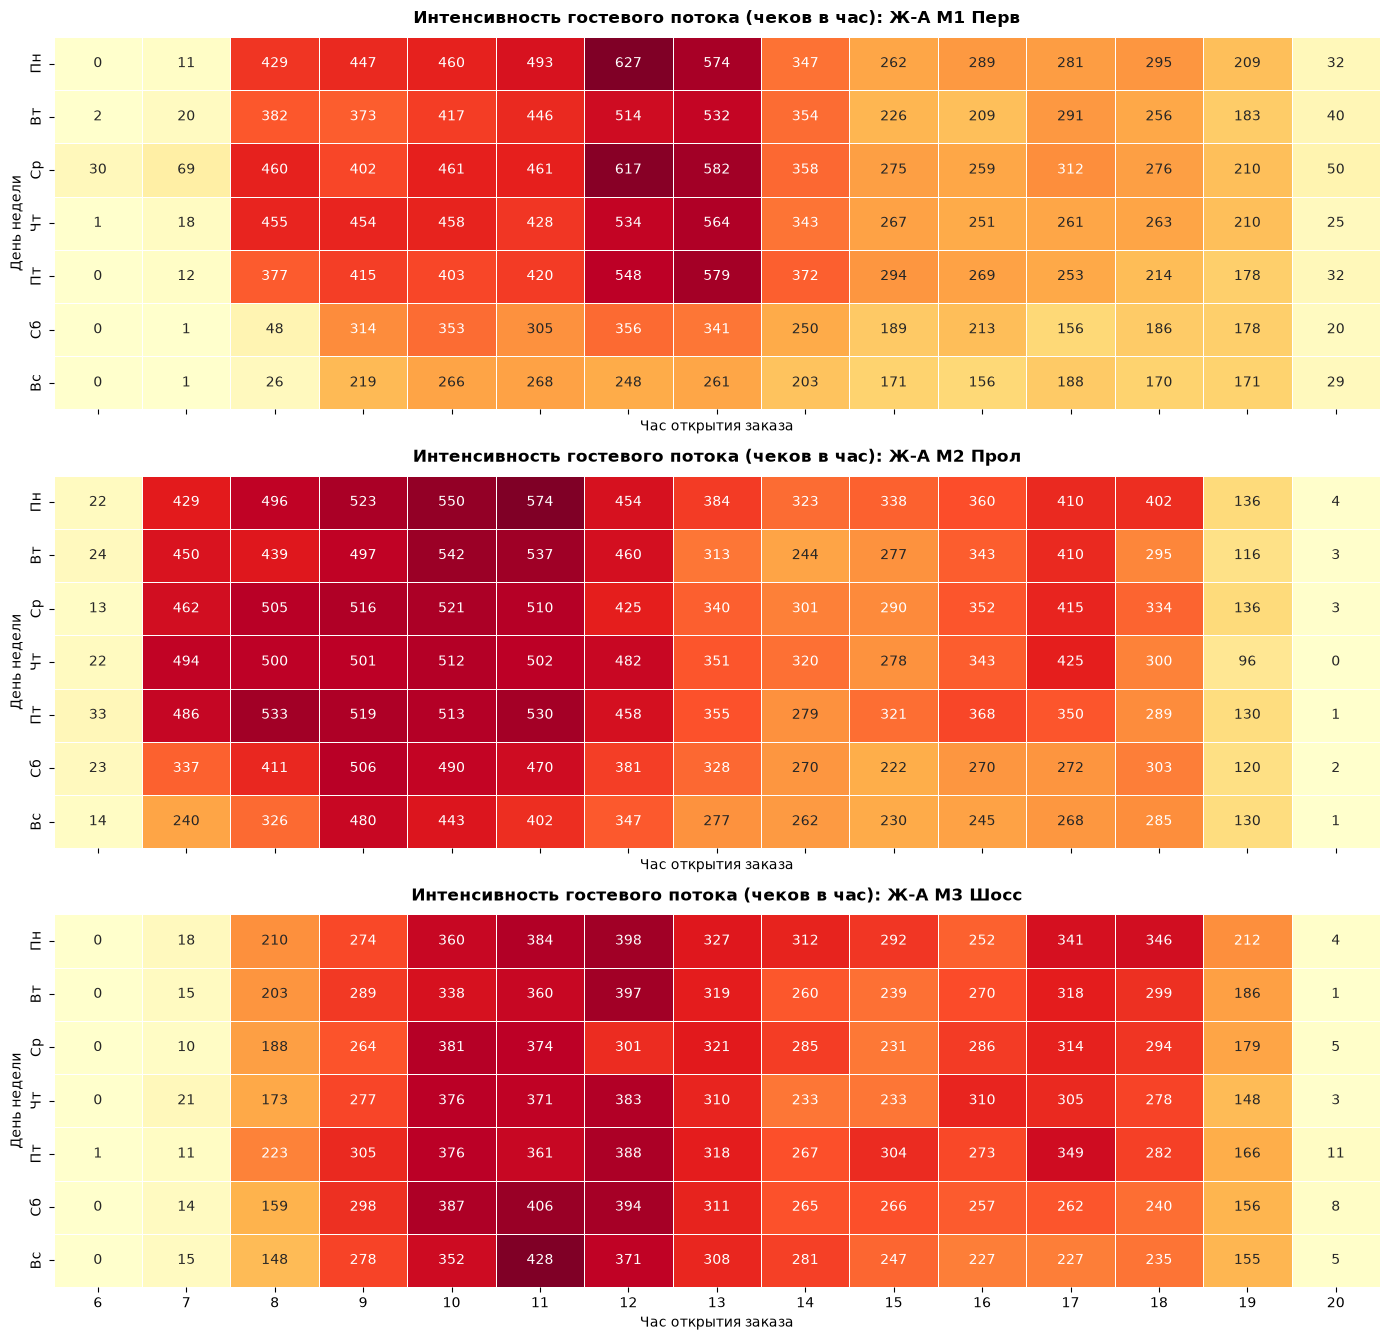

In [26]:
# 1. Задаем корректный порядок дней недели
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days_ru = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_map = dict(zip(days_order, days_ru))

df['day_name_ru'] = df['day_of_week'].map(day_map)
ru_order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# 2. Строим тепловые карты для каждой ТТ
unique_tts = df['Торговое предприятие'].unique()
fig, axes = plt.subplots(len(unique_tts), 1, figsize=(14, 4.5 * len(unique_tts)), sharex=True)

for ax, tt in zip(axes, unique_tts):
    # Считаем уникальные чеки по часам и дням недели для точки
    tt_data = df[df['Торговое предприятие'] == tt]
    heatmap_data = tt_data.groupby(['day_name_ru', 'hour'])['order_id'].nunique().unstack(fill_value=0)
    
    # Сортируем дни недели по порядку
    heatmap_data = heatmap_data.reindex(ru_order)
    
    # Визуализация
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, annot=True, fmt='d', cbar=False, linewidths=0.5)
    ax.set_title(f'Интенсивность гостевого потока (чеков в час): {tt}', fontsize=12, weight='bold', pad=10)
    ax.set_ylabel('День недели', fontsize=10)
    ax.set_xlabel('Час открытия заказа', fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
# 1. Классифицируем строки на Еду, Напитки и Прочее
def classify_category(cat):
    cat_str = str(cat).lower()
    if any(x in cat_str for x in ['кофе', 'чай', 'лимонад', 'напитки']):
        return 'Напиток'
    elif any(x in cat_str for x in ['сопутствующие', 'упаковка']):
        return 'Упаковка/Прочее'
    else:
        return 'Еда'

df['item_type'] = df['Категория блюда'].apply(classify_category)

# 2. Агрегируем состав каждого заказа
order_composition = df[df['item_type'] != 'Упаковка/Прочее'].groupby('order_id')['item_type'].unique()

def get_basket_type(types):
    types_set = set(types)
    if 'Еда' in types_set and 'Напиток' in types_set:
        return 'Еда + Напиток'
    elif 'Напиток' in types_set:
        return 'Только напиток'
    elif 'Еда' in types_set:
        return 'Только еда'
    return 'Прочее'

basket_analysis = order_composition.apply(get_basket_type).value_counts(normalize=True) * 100

print("=== СТРУКТУРА КОРЗИНЫ ПО ВСЕЙ СЕТИ ===")
for basket_type, pct in basket_analysis.items():
    print(f"{basket_type}: {pct:.1f}%")

=== СТРУКТУРА КОРЗИНЫ ПО ВСЕЙ СЕТИ ===
Только еда: 63.2%
Еда + Напиток: 34.7%
Только напиток: 2.2%


In [28]:
# 1. Ищем напитки с нулевой стоимостью или упоминанием акции/подарка/комбо
drink_mask = df['item_type'] == 'Напиток'
promo_mask = (
    (df['Сумма со скидкой, р.'] == 0) | 
    df['Блюдо'].astype(str).str.contains('комбо|подарок|акци|бесплатн', case=False, na=False)
)

print("--- ТОП БЕСПЛАТНЫХ / АКЦИОННЫХ НАПИТКОВ В ЧЕКАХ ---")
print(df[drink_mask & promo_mask]['Блюдо'].value_counts().head(15))

# 2. Проверяем также эклеры: как они пробивались
print("\n--- СТРОКИ С ЭКЛЕРАМИ В ЧЕКАХ ---")
print(df[df['Блюдо'].astype(str).str.contains('Эклер', case=False, na=False)]['Блюдо'].value_counts().head(10))

--- ТОП БЕСПЛАТНЫХ / АКЦИОННЫХ НАПИТКОВ В ЧЕКАХ ---
Блюдо
Американо 250мл             37
Капучино 350 мл             36
Айс- латте                  29
Оштен 0,5 ПЭТ               26
Латте 350мл                 22
Капучино 250мл              16
Лимонад в асс-те 0,33 ЖБ    15
Флет Уайт 250мл             14
Чай черный 350мл            10
Латте 450мл                  9
Бамбл                        9
Лимонад оранжад 500мл        8
Лимонад Клубника-базилик     8
Капучино 450мл               7
Сок 0,2                      6
Name: count, dtype: int64

--- СТРОКИ С ЭКЛЕРАМИ В ЧЕКАХ ---
Блюдо
Эклер Жак-Андрэ       1231
Эклер классический    1168
Эклер Фрез             985
Эклер фисташковый      707
Эклер шоколадный       527
Эклер Наполеон         176
Эклер карамельный      116
Name: count, dtype: int64


In [29]:
print("Все категории меню в датасете:")
print(df['Категория блюда'].value_counts(dropna=False))

Все категории меню в датасете:
Категория блюда
Сопутствующие товары          119854
Выпечка                        60261
Хлеб                           34009
Сэндвичи                       26882
NaN                            25091
Кофе                           19919
Лимонад (холодные напитки)     16302
Десерты                         9880
Эклеры                          4910
Пирожные                        4544
Торты                           4095
Пироги                          3959
Чай                             3369
Боул                            2856
Тарталетки                      2300
Печенье                         1163
Молочный коктель                 439
Компоты                          400
Трайфлы                          209
Смузи                            129
Name: count, dtype: int64


In [30]:
# 1. Точная разметка товарных групп
def assign_group(cat):
    cat_str = str(cat).lower()
    if cat_str in ['кофе', 'чай']:
        return 'Горячий напиток'
    elif any(x in cat_str for x in ['лимонад', 'компоты', 'смузи', 'молочный коктейль']):
        return 'Холодный напиток'
    elif cat_str in ['выпечка', 'эклеры']:
        return 'Целевая выпечка/Эклер'
    elif cat_str in ['сопутствующие товары']:
        return 'Упаковка'
    return 'Прочая еда'

df['menu_group'] = df['Категория блюда'].apply(assign_group)

# 2. Агрегация состава по чекам
order_groups = df[df['menu_group'] != 'Упаковка'].groupby(['order_id', 'Торговое предприятие'])['menu_group'].unique().reset_index()

# Флаги наличия категорий в чеке
order_groups['has_target_pastry'] = order_groups['menu_group'].apply(lambda x: 'Целевая выпечка/Эклер' in x)
order_groups['has_hot_drink'] = order_groups['menu_group'].apply(lambda x: 'Горячий напиток' in x)
order_groups['is_combo'] = order_groups['has_target_pastry'] & order_groups['has_hot_drink']

# 3. Метрики проникновения комбо по торговым точкам
combo_stats = order_groups.groupby('Торговое предприятие').agg(
    всего_чеков=('order_id', 'count'),
    чеков_с_выпечкой=('has_target_pastry', 'sum'),
    чеков_комбо=('is_combo', 'sum')
).reset_index()

# Конверсия: процент чеков с выпечкой, где был докуплен горячий напиток (комбо)
combo_stats['доля_комбо_от_всех_%'] = (combo_stats['чеков_комбо'] / combo_stats['всего_чеков'] * 100).round(2)
combo_stats['конверсия_в_напиток_%'] = (combo_stats['чеков_комбо'] / combo_stats['чеков_с_выпечкой'] * 100).round(2)

print("=== ЭФФЕКТИВНОСТЬ СВЯЗКИ ВЫПЕЧКА/ЭКЛЕР + ГОРЯЧИЙ НАПИТОК ===")
print(combo_stats.to_string(index=False))

=== ЭФФЕКТИВНОСТЬ СВЯЗКИ ВЫПЕЧКА/ЭКЛЕР + ГОРЯЧИЙ НАПИТОК ===
Торговое предприятие  всего_чеков  чеков_с_выпечкой  чеков_комбо  доля_комбо_от_всех_%  конверсия_в_напиток_%
         Ж-А М1 Перв        27878             13964         4533                 16.26                  32.46
         Ж-А М2 Прол        29442             17616         8799                 29.89                  49.95
         Ж-А М3 Шосс        24214              9652         3839                 15.85                  39.77


In [31]:
import json

# 1. Функция расчета ABC-рангов
def calc_abc(df_subset):
    res = df_subset.groupby(['Блюдо', 'Категория блюда']).agg(
        выручка=('Сумма со скидкой, р.', 'sum'),
        маржа=('margin', 'sum'),
        кол_во=('Количество блюд', 'sum')
    ).reset_index()
    
    for col in ['маржа', 'выручка', 'кол_во']:
        res = res.sort_values(by=col, ascending=False)
        cum_share = res[col].cumsum() / res[col].sum()
        res['abc_' + col] = np.select([cum_share <= 0.80, cum_share <= 0.95], ['A', 'B'], default='C')
        
    res['food_cost_%'] = (((res['выручка'] - res['маржа']) / res['выручка']) * 100).round(1)
    return res

# 2. Собираем данные по месяцам и за весь период
records = []

# За все лето
all_df = calc_abc(df)
all_df['Период'] = 'Все лето'
records.append(all_df)

# По каждому месяцу отдельно
for m in ['June', 'July', 'August']:
    sub = df[df['month'] == m]
    if len(sub) > 0:
        sub_df = calc_abc(sub)
        sub_df['Период'] = m
        records.append(sub_df)

export_df = pd.concat(records, ignore_index=True)

# Форматируем отображение чисел
export_df['выручка_fmt'] = export_df['выручка'].map('{:,.0f} ₽'.format)
export_df['маржа_fmt'] = export_df['маржа'].map('{:,.0f} ₽'.format)
export_df['кол_во_fmt'] = export_df['кол_во'].map('{:,.0f} шт'.format)

# 3. Генерируем автономную страницу index.html с интерфейсом iiko
data_json = export_df.to_dict(orient='records')

html_template = f"""<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <title>ABC-анализ ассортимента (iiko style)</title>
    <link rel="stylesheet" href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.min.css">
    <link rel="stylesheet" href="https://cdn.datatables.net/buttons/2.4.1/css/buttons.dataTables.min.css">
    <style>
        body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; margin: 20px; background: #f8f9fa; color: #333; }}
        h2 {{ margin-bottom: 5px; }}
        .controls {{ display: flex; gap: 15px; align-items: center; margin: 15px 0 20px 0; background: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); }}
        .badge {{ font-weight: bold; padding: 4px 10px; border-radius: 4px; display: inline-block; min-width: 20px; text-align: center; }}
        .badge-A {{ background-color: #2ecc71; color: #fff; }}
        .badge-B {{ background-color: #f1c40f; color: #222; }}
        .badge-C {{ background-color: #ff7675; color: #fff; }}
        table.dataTable thead th {{ background: #2c3e50; color: #fff; text-align: left; }}
        select {{ padding: 6px 12px; font-size: 14px; border-radius: 4px; border: 1px solid #ccc; }}
    </style>
</head>
<body>
    <h2>Матрица ABC-анализа меню</h2>
    <p style="color: #666; font-size: 14px;">Интерактивная таблица с фильтрацией по месяцам, поиском и подсветкой групп</p>
    
    <div class="controls">
        <label><b>Период:</b></label>
        <select id="periodFilter">
            <option value="Все лето">Все лето</option>
            <option value="June">Июнь</option>
            <option value="July">Июль</option>
            <option value="August">Август</option>
        </select>
    </div>

    <table id="abcTable" class="display cell-border" style="width:100%; background: #fff;">
        <thead>
            <tr>
                <th>Блюдо</th>
                <th>Категория</th>
                <th>Маржа (ABC)</th>
                <th>Выручка (ABC)</th>
                <th>Кол-во (ABC)</th>
                <th>Выручка, ₽</th>
                <th>Маржа, ₽</th>
                <th>Food Cost %</th>
                <th>Продажи, шт</th>
            </tr>
        </thead>
        <tbody></tbody>
    </table>

    <script src="https://code.jquery.com/jquery-3.7.0.min.js"></script>
    <script src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.min.js"></script>
    <script>
        const rawData = {json.dumps(data_json, ensure_ascii=False)};
        
        function getBadge(val) {{
            return `<span class="badge badge-${{val}}">${{val}}</span>`;
        }}

        $(document).ready(function() {{
            const table = $('#abcTable').DataTable({{
                data: rawData.filter(d => d.Период === 'Все лето'),
                columns: [
                    {{ data: 'Блюдо' }},
                    {{ data: 'Категория блюда' }},
                    {{ data: 'abc_маржа', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_выручка', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_кол_во', render: getBadge, className: 'dt-center' }},
                    {{ data: 'выручка_fmt' }},
                    {{ data: 'маржа_fmt' }},
                    {{ data: 'food_cost_%', render: d => d + '%' }},
                    {{ data: 'кол_во_fmt' }}
                ],
                pageLength: 25,
                order: [[5, 'desc']],
                language: {{
                    search: "Поиск позиции:",
                    lengthMenu: "Показывать по _MENU_ строк",
                    info: "Показано с _START_ по _END_ из _TOTAL_ блюд",
                    paginate: {{ next: "Вперед", previous: "Назад" }}
                }}
            }});

            $('#periodFilter').on('change', function() {{
                const selected = $(this).val();
                table.clear();
                table.rows.add(rawData.filter(d => d.Период === selected));
                table.draw();
            }});
        }});
    </script>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Файл index.html успешно сгенерирован в рабочей директории!")

Файл index.html успешно сгенерирован в рабочей директории!


In [35]:
# Цвета бейджей в точности как в интерфейсе iiko
def color_abc(val):
    if val == 'A':
        return 'background-color: #2ecc71; color: white; font-weight: bold; text-align: center;'
    elif val == 'B':
        return 'background-color: #f1c40f; color: black; font-weight: bold; text-align: center;'
    elif val == 'C':
        return 'background-color: #ff7675; color: white; font-weight: bold; text-align: center;'
    return ''

# Используем all_df, где уже есть категории и расчеты по Выручке, Марже и Количеству
styled_view = (
    all_df[[
        'Блюдо', 'Категория блюда', 
        'abc_маржа', 'abc_выручка', 'abc_кол_во',
        'маржа', 'выручка', 'food_cost_%', 'кол_во'
    ]]
    .sort_values('выручка', ascending=False)
    .head(30)
    .style
    .map(color_abc, subset=['abc_маржа', 'abc_выручка', 'abc_кол_во'])
    .format({
        'выручка': '{:,.0f} ₽',
        'маржа': '{:,.0f} ₽',
        'food_cost_%': '{:.1f}%',
        'кол_во': '{:,.0f} шт'
    })
)

styled_view

,Блюдо,Категория блюда,abc_маржа,abc_выручка,abc_кол_во,маржа,выручка,food_cost_%,кол_во
51,Клаб- сэндвич с индейкой,Сэндвичи,A,A,A,"1,093,045 ₽","1,411,829 ₽",22.6%,"6,761 шт"
52,Клаб- сэндвич с курицей,Сэндвичи,A,A,A,"1,044,646 ₽","1,387,141 ₽",24.7%,"6,647 шт"
43,Капучино 350 мл,Кофе,A,A,A,"859,402 ₽","1,192,710 ₽",27.9%,"5,964 шт"
130,Панини Пуле,Сэндвичи,A,A,A,"775,710 ₽","1,100,279 ₽",29.5%,"6,522 шт"
266,Чиабатта на закваске,Хлеб,A,A,A,"687,514 ₽","1,016,597 ₽",32.4%,"20,442 шт"
50,Клаб - сэндвич с рыбой,Сэндвичи,A,A,A,"612,733 ₽","1,007,662 ₽",39.2%,"2,816 шт"
73,Круассан сыр,Выпечка,A,A,A,"434,724 ₽","842,949 ₽",48.4%,"10,054 шт"
222,Торт Марадона,Торты,A,A,C,"686,183 ₽","825,741 ₽",16.9%,426 шт
102,Макаронсы,Десерты,A,A,C,"388,671 ₽","805,875 ₽",51.8%,231 шт
214,Торт Амели,Торты,A,A,B,"396,308 ₽","763,038 ₽",48.1%,592 шт


In [36]:
import json
import numpy as np
import pandas as pd

# 1. Фильтруем датасет: исключаем упаковку и сопутствующие товары
df_menu = df[df['Категория блюда'].astype(str).str.strip().str.lower() != 'сопутствующие товары'].copy()

# 2. Функция расчета ABC-рангов строго по позициям меню
def calc_abc_clean(df_subset):
    res = df_subset.groupby(['Блюдо', 'Категория блюда']).agg(
        выручка=('Сумма со скидкой, р.', 'sum'),
        маржа=('margin', 'sum'),
        кол_во=('Количество блюд', 'sum')
    ).reset_index()
    
    for col in ['маржа', 'выручка', 'кол_во']:
        res = res.sort_values(by=col, ascending=False)
        cum_share = res[col].cumsum() / res[col].sum()
        res['abc_' + col] = np.select([cum_share <= 0.80, cum_share <= 0.95], ['A', 'B'], default='C')
        
    res['food_cost_%'] = (((res['выручка'] - res['маржа']) / res['выручка']) * 100).round(1)
    return res

# 3. Собираем данные по периодам
records_clean = []

# За все лето
all_clean = calc_abc_clean(df_menu)
all_clean['Период'] = 'Все лето'
records_clean.append(all_clean)

# По месяцам
for m in ['June', 'July', 'August']:
    sub = df_menu[df_menu['month'] == m]
    if len(sub) > 0:
        sub_df = calc_abc_clean(sub)
        sub_df['Период'] = m
        records_clean.append(sub_df)

export_clean_df = pd.concat(records_clean, ignore_index=True)

# Форматирование числовых значений
export_clean_df['выручка_fmt'] = export_clean_df['выручка'].map('{:,.0f} ₽'.format)
export_clean_df['маржа_fmt'] = export_clean_df['маржа'].map('{:,.0f} ₽'.format)
export_clean_df['кол_во_fmt'] = export_clean_df['кол_во'].map('{:,.0f} шт'.format)

# 4. Перезаписываем index.html
clean_json = export_clean_df.to_dict(orient='records')

html_template = f"""<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <title>ABC-анализ ассортимента (iiko style)</title>
    <link rel="stylesheet" href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.min.css">
    <link rel="stylesheet" href="https://cdn.datatables.net/buttons/2.4.1/css/buttons.dataTables.min.css">
    <style>
        body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; margin: 20px; background: #f8f9fa; color: #333; }}
        h2 {{ margin-bottom: 5px; }}
        .controls {{ display: flex; gap: 15px; align-items: center; margin: 15px 0 20px 0; background: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); }}
        .badge {{ font-weight: bold; padding: 4px 10px; border-radius: 4px; display: inline-block; min-width: 20px; text-align: center; }}
        .badge-A {{ background-color: #2ecc71; color: #fff; }}
        .badge-B {{ background-color: #f1c40f; color: #222; }}
        .badge-C {{ background-color: #ff7675; color: #fff; }}
        table.dataTable thead th {{ background: #2c3e50; color: #fff; text-align: left; }}
        select {{ padding: 6px 12px; font-size: 14px; border-radius: 4px; border: 1px solid #ccc; }}
    </style>
</head>
<body>
    <h2>Матрица ABC-анализа меню</h2>
    <p style="color: #666; font-size: 14px;">Чистый срез по позициям кухни и бара (без сопутствующей тары и упаковки)</p>
    
    <div class="controls">
        <label><b>Период:</b></label>
        <select id="periodFilter">
            <option value="Все лето">Все лето</option>
            <option value="June">Июнь</option>
            <option value="July">Июль</option>
            <option value="August">Август</option>
        </select>
    </div>

    <table id="abcTable" class="display cell-border" style="width:100%; background: #fff;">
        <thead>
            <tr>
                <th>Блюдо</th>
                <th>Категория</th>
                <th>Маржа (ABC)</th>
                <th>Выручка (ABC)</th>
                <th>Кол-во (ABC)</th>
                <th>Выручка, ₽</th>
                <th>Маржа, ₽</th>
                <th>Food Cost %</th>
                <th>Продажи, шт</th>
            </tr>
        </thead>
        <tbody></tbody>
    </table>

    <script src="https://code.jquery.com/jquery-3.7.0.min.js"></script>
    <script src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.min.js"></script>
    <script>
        const rawData = {json.dumps(clean_json, ensure_ascii=False)};
        
        function getBadge(val) {{
            return `<span class="badge badge-${{val}}">${{val}}</span>`;
        }}

        $(document).ready(function() {{
            const table = $('#abcTable').DataTable({{
                data: rawData.filter(d => d.Период === 'Все лето'),
                columns: [
                    {{ data: 'Блюдо' }},
                    {{ data: 'Категория блюда' }},
                    {{ data: 'abc_маржа', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_выручка', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_кол_во', render: getBadge, className: 'dt-center' }},
                    {{ data: 'выручка_fmt' }},
                    {{ data: 'маржа_fmt' }},
                    {{ data: 'food_cost_%', render: d => d + '%' }},
                    {{ data: 'кол_во_fmt' }}
                ],
                pageLength: 25,
                order: [[5, 'desc']],
                language: {{
                    search: "Поиск позиции:",
                    lengthMenu: "Показывать по _MENU_ строк",
                    info: "Показано с _START_ по _END_ из _TOTAL_ блюд",
                    paginate: {{ next: "Вперед", previous: "Назад" }}
                }}
            }});

            $('#periodFilter').on('change', function() {{
                const selected = $(this).val();
                table.clear();
                table.rows.add(rawData.filter(d => d.Период === selected));
                table.draw();
            }});
        }});
    </script>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print(f"Готово! Строк меню без упаковки: {len(df_menu):,}")
print("Файл index.html успешно обновлен!")

Готово! Строк меню без упаковки: 220,717
Файл index.html успешно обновлен!


In [37]:
import json
import numpy as np
import pandas as pd

# 1. Берем меню без упаковки
df_menu = df[df['Категория блюда'].astype(str).str.strip().str.lower() != 'сопутствующие товары'].copy()

# 2. Функция расчета ABC-рангов
def calc_abc_slice(df_subset, period_label, tt_label):
    if len(df_subset) == 0:
        return pd.DataFrame()
        
    res = df_subset.groupby(['Блюдо', 'Категория блюда']).agg(
        выручка=('Сумма со скидкой, р.', 'sum'),
        маржа=('margin', 'sum'),
        кол_во=('Количество блюд', 'sum')
    ).reset_index()
    
    for col in ['маржа', 'выручка', 'кол_во']:
        res = res.sort_values(by=col, ascending=False)
        cum_share = res[col].cumsum() / res[col].sum()
        res['abc_' + col] = np.select([cum_share <= 0.80, cum_share <= 0.95], ['A', 'B'], default='C')
        
    res['food_cost_%'] = (((res['выручка'] - res['маржа']) / res['выручка']) * 100).round(1)
    res['Период'] = period_label
    res['ТТ'] = tt_label
    return res

# 3. Формируем комбинации: Период x Торговая точка
all_periods = [('Все лето', df_menu)] + [
    (m, df_menu[df_menu['month'] == m]) for m in ['June', 'July', 'August'] if len(df_menu[df_menu['month'] == m]) > 0
]

all_tts = ['Вся сеть'] + list(df_menu['Торговое предприятие'].dropna().unique())

records = []
for p_label, p_df in all_periods:
    for tt in all_tts:
        if tt == 'Вся сеть':
            subset = p_df
        else:
            subset = p_df[p_df['Торговое предприятие'] == tt]
            
        slice_res = calc_abc_slice(subset, p_label, tt)
        if not slice_res.empty:
            records.append(slice_res)

export_df = pd.concat(records, ignore_index=True)

# Форматирование цифр
export_df['выручка_fmt'] = export_df['выручка'].map('{:,.0f} ₽'.format)
export_df['маржа_fmt'] = export_df['маржа'].map('{:,.0f} ₽'.format)
export_df['кол_во_fmt'] = export_df['кол_во'].map('{:,.0f} шт'.format)

# 4. Создаем index.html с селекторами Периода и ТТ
data_json = export_df.to_dict(orient='records')
tt_options = "".join([f'<option value="{tt}">{tt}</option>' for tt in all_tts])

html_template = f"""<!DOCTYPE html>
<html lang="ru">
<head>
    <meta charset="UTF-8">
    <title>ABC-анализ ассортимента (iiko style)</title>
    <link rel="stylesheet" href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.min.css">
    <link rel="stylesheet" href="https://cdn.datatables.net/buttons/2.4.1/css/buttons.dataTables.min.css">
    <style>
        body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; margin: 20px; background: #f8f9fa; color: #333; }}
        h2 {{ margin-bottom: 5px; }}
        .controls {{ display: flex; flex-wrap: wrap; gap: 20px; align-items: center; margin: 15px 0 20px 0; background: #fff; padding: 15px; border-radius: 8px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); }}
        .control-group {{ display: flex; align-items: center; gap: 8px; }}
        .badge {{ font-weight: bold; padding: 4px 10px; border-radius: 4px; display: inline-block; min-width: 20px; text-align: center; }}
        .badge-A {{ background-color: #2ecc71; color: #fff; }}
        .badge-B {{ background-color: #f1c40f; color: #222; }}
        .badge-C {{ background-color: #ff7675; color: #fff; }}
        table.dataTable thead th {{ background: #2c3e50; color: #fff; text-align: left; }}
        select {{ padding: 6px 12px; font-size: 14px; border-radius: 4px; border: 1px solid #ccc; background: #fff; }}
    </style>
</head>
<body>
    <h2>Матрица ABC-анализа меню</h2>
    <p style="color: #666; font-size: 14px;">Интерактивный срез без сопутствующих товаров с независимым пересчетом рангов по периодам и локациям</p>
    
    <div class="controls">
        <div class="control-group">
            <label><b>Период:</b></label>
            <select id="periodFilter">
                <option value="Все лето">Все лето</option>
                <option value="June">Июнь</option>
                <option value="July">Июль</option>
                <option value="August">Август</option>
            </select>
        </div>
        <div class="control-group">
            <label><b>Торговая точка:</b></label>
            <select id="ttFilter">
                {tt_options}
            </select>
        </div>
    </div>

    <table id="abcTable" class="display cell-border" style="width:100%; background: #fff;">
        <thead>
            <tr>
                <th>Блюдо</th>
                <th>Категория</th>
                <th>Маржа (ABC)</th>
                <th>Выручка (ABC)</th>
                <th>Кол-во (ABC)</th>
                <th>Выручка, ₽</th>
                <th>Маржа, ₽</th>
                <th>Food Cost %</th>
                <th>Продажи, шт</th>
            </tr>
        </thead>
        <tbody></tbody>
    </table>

    <script src="https://code.jquery.com/jquery-3.7.0.min.js"></script>
    <script src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.min.js"></script>
    <script>
        const rawData = {json.dumps(data_json, ensure_ascii=False)};
        
        function getBadge(val) {{
            return `<span class="badge badge-${{val}}">${{val}}</span>`;
        }}

        $(document).ready(function() {{
            function getFilteredData() {{
                const selectedPeriod = $('#periodFilter').val();
                const selectedTT = $('#ttFilter').val();
                return rawData.filter(d => d.Период === selectedPeriod && d.ТТ === selectedTT);
            }}

            const table = $('#abcTable').DataTable({{
                data: getFilteredData(),
                columns: [
                    {{ data: 'Блюдо' }},
                    {{ data: 'Категория блюда' }},
                    {{ data: 'abc_маржа', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_выручка', render: getBadge, className: 'dt-center' }},
                    {{ data: 'abc_кол_во', render: getBadge, className: 'dt-center' }},
                    {{ data: 'выручка_fmt' }},
                    {{ data: 'маржа_fmt' }},
                    {{ data: 'food_cost_%', render: d => d + '%' }},
                    {{ data: 'кол_во_fmt' }}
                ],
                pageLength: 25,
                order: [[5, 'desc']],
                language: {{
                    search: "Поиск позиции:",
                    lengthMenu: "Показывать по _MENU_ строк",
                    info: "Показано с _START_ по _END_ из _TOTAL_ блюд",
                    paginate: {{ next: "Вперед", previous: "Назад" }}
                }}
            }});

            $('#periodFilter, #ttFilter').on('change', function() {{
                table.clear();
                table.rows.add(getFilteredData());
                table.draw();
            }});
        }});
    </script>
</body>
</html>"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("Файл index.html успешно обновлен с поддержкой фильтрации по ТТ и периодам!")

Файл index.html успешно обновлен с поддержкой фильтрации по ТТ и периодам!
